Introduction:

Sabrina and I are Microbiology majors, and have served as teaching assistants for MCB3023L; a core Microbiology laboratory class. A key part of the class is the lab practical, which constitutes a large part of the students' grades. It is notorious for being long and difficult.\

We wanted to investigate factors potentially related to performance on the lab practical so that we could help our professor and her future students.

Data Collection:

We started off by creating a survey for MCB3023L asking several questions related to 1) their letter grade performance on the practical and 2) their studying/learning habits related to the lab practical.

We then had to obtain IRB-exemption (since we are collected data off of people) and sponsorship from our professor of whom we TA'd for.

The next part involved contacting three professors who teach MCB3023L and requesting they distribute the survey to their students. 

After data was collected, we began with preprocessing.


A look at the questions asked on the survey: 

How often did you pay close attention during lab sessions?

How many times did you come into the lab outside of class to practice techniques?

How confident were you in your lab techniques before the practical? (rate 1-5 )

How anxious were you about the lab practical? (rate 1-5 )

How many hours per week did you study or review lab materials?

Helpfulness in Studying: Lab Manual (rate 1-5 stars)

Helpfulness in Studying: Quizlet (rate 1-5 stars)

Helpfulness in Studying: Lab Slides (rate 1-5 stars)

Helpfulness in Studying: ELNs (rate 1-5 stars)

Helpfulness in Studying: ChatGPT (rate 1-5 stars)

Do you or have you worked or volunteered in a lab setting outside of MCB3023L? (yes or no)

What grade did you receive on the lab practical? ← (Target!! What we want to predict!! Asked as Letter Grade, not Numerical grade)

🧼 Data Preprocessing
First, we imported the dataset using pandas. Since we don't need the timestamp for our analysis, we dropped that column right away. We also made sure to clean up the column names by stripping any extra whitespace — just in case there were formatting issues from Google Forms.

In [68]:
import pandas as pd

# Load the dataset
file_path = "./MCB3032L (Responses) - Form Responses 1.csv"
df = pd.read_csv(file_path)

# Drop the timestamp column bc we do not need it
df = df.drop(columns=["Timestamp"], errors='ignore')

# Strip leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Preview the first few rows
df.head()


,How often did you pay close attention during lab sessions?,"How many times did you come into the lab outside of class to practice techniques? (specifically, the instances were class was dismissed and you stayed to work on techniques, or if you came in at your own times)",How confident were you in your lab techniques before the practical?,How anxious were you about the lab practical?,How many hours per week did you study or review lab materials?,Helpfulness in Studying: Lab Manual,Helpfulness in Studying: Quizlet,Helpfulness in Studying: Lab Slides,Helpfulness in Studying: ELNs,Helpfulness in Studying: ChatGPT,"Do you or have you worked or volunteered in a lab setting outside of MCB3023L, where you use techniques you have learned in MCB3032L?",What grade did you receive on the lab practical?
0,most of the time,0 times,5,3,less than 1 hour,3,1,4,5,1,yes,A (90-100)
1,most of the time,2-3 times,5,2,1-2 hours,1,1,2,1,1,yes,D (60-69)
2,most of the time,2-3 times,4,2,1-2 hours,3,1,5,5,4,yes,B (80-89)
3,most of the time,2-3 times,3,3,less than 1 hour,2,2,5,4,1,yes,B (80-89)
4,most of the time,2-3 times,3,5,less than 1 hour,2,1,3,4,4,yes,B (80-89)


Looking at the data, there is a lot an ML algorithm is not going to get unless we encode it in some way. We have to convert the responses into numerical or Boolean form. 
To prepare our data for modeling, we need to convert some of the survey responses from text into numeric values. This is important because machine learning models don’t work well with raw strings — they need numerical inputs to learn from patterns.

We created a new copy of the dataset and renamed the column containing final lab grades to "Grade" for convenience. Then, we applied ordinal encoding to several of the survey questions that had a natural order (e.g., "never" to "always", or "0 times" to "4+ times").

We also applied binary encoding to the yes/no question about lab experience.

-These mappings are based on all possible answer choices from the original survey — even if not all of them appear in the current data. This ensures our encoding will still work if we collect more responses later.

Before applying the mappings, we checked each column to make sure there were no unexpected answers (misspelled values, blanks, etc.). If any responses didn’t match what we expected, they would show up in the output as “unmapped.”

In [69]:
# Make a fresh copy to encode
df_encoded = df.copy()

# Rename the target column to 'Grade' for convenience
df_encoded.rename(columns={
    "What grade did you receive on the lab practical?": "Grade"
}, inplace=True)

# Define mapping dictionaries for all survey questions (based on original form, not just present values)
ordinal_maps = {
    "How often did you pay close attention during lab sessions?": {
        "never": 1,
        "rarely": 2,
        "sometimes": 3,
        "most of the time": 4,
        "always": 5
    },
    "How many times did you come into the lab outside of class to practice techniques? (specifically, the instances were class was dismissed and you stayed to work on techniques, or if you came in at your own times)": {
        "0 times": 0,
        "1 time": 1,
        "2-3 times": 2,
        "4+ times": 3
    },
    "How many hours per week did you study or review lab materials?": {
        "less than 1 hour": 0,
        "1-2 hours": 1,
        "3-4 hours": 2,
        "5+ hours": 3
    },
    "Do you or have you worked or volunteered in a lab setting outside of MCB3023L, where you use techniques you have learned in MCB3032L?": {
        "no": 0,
        "yes": 1
    }
}

# Optional: Check for any values that aren't mapped (useful when cleaning or adding more data)
print("🔍 Unmapped values (if any):")
for col, mapping in ordinal_maps.items():
    if col in df_encoded.columns:
        print(f"\n{col}")
        for val in df_encoded[col].dropna().unique():
            if val not in mapping:
                print(f"  ❗ Unmapped value: '{val}'")

# Apply the mappings to convert text to numeric values
for col, mapping in ordinal_maps.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)

# Preview the encoded data
df_encoded.head()


🔍 Unmapped values (if any):

How often did you pay close attention during lab sessions?

How many times did you come into the lab outside of class to practice techniques? (specifically, the instances were class was dismissed and you stayed to work on techniques, or if you came in at your own times)

How many hours per week did you study or review lab materials?

Do you or have you worked or volunteered in a lab setting outside of MCB3023L, where you use techniques you have learned in MCB3032L?


,How often did you pay close attention during lab sessions?,"How many times did you come into the lab outside of class to practice techniques? (specifically, the instances were class was dismissed and you stayed to work on techniques, or if you came in at your own times)",How confident were you in your lab techniques before the practical?,How anxious were you about the lab practical?,How many hours per week did you study or review lab materials?,Helpfulness in Studying: Lab Manual,Helpfulness in Studying: Quizlet,Helpfulness in Studying: Lab Slides,Helpfulness in Studying: ELNs,Helpfulness in Studying: ChatGPT,"Do you or have you worked or volunteered in a lab setting outside of MCB3023L, where you use techniques you have learned in MCB3032L?",Grade
0,4,0,5,3,0,3,1,4,5,1,1,A (90-100)
1,4,2,5,2,1,1,1,2,1,1,1,D (60-69)
2,4,2,4,2,1,3,1,5,5,4,1,B (80-89)
3,4,2,3,3,0,2,2,5,4,1,1,B (80-89)
4,4,2,3,5,0,2,1,3,4,4,1,B (80-89)


🧼 Handling Missing Values

After encoding our ordinal and binary responses, it's possible that some values are now missing (NaNs). This can happen if a student skipped a question or if their response didn’t exactly match one of the mapped options.

Before we can train any models, we need to make sure the dataset is complete — missing values can break most machine learning algorithms.

We’ll first check how many values are missing, and then decide how to handle them.

In [70]:
# Check how many missing values there are in each column
df_encoded.isnull().sum()
# See how many total rows are affected
df_encoded.isnull().any(axis=1).sum()

np.int64(0)

If only a few rows are missing data, we’ll drop them for now. This keeps the dataset clean and simplifies modeling.

In [71]:
# Drop rows with any missing values
df_encoded = df_encoded.dropna()

# Confirm it's clean
df_encoded.isnull().sum().sum()  # should be 0


np.int64(0)

Note: For larger datasets, or if you don’t want to lose data, another option would be to fill missing values using something like the column average or most common response (mode). But since our dataset is small, dropping is the simpler and safer option for now.

 Exploring the Cleaned Dataset Visually
Now that our dataset is fully encoded and free of missing values, it’s helpful to take a quick look at the distributions of key features and see how they relate to the target variable: Grade.

Let’s start with some basic visualizations to understand:

How grades are distributed

How features like confidence or anxiety relate to grade

Whether any features are highly correlated

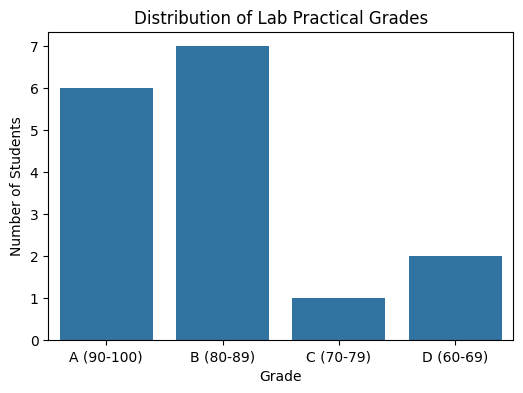

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot for the target variable
plt.figure(figsize=(6,4))
sns.countplot(x="Grade", data=df_encoded, order=sorted(df_encoded["Grade"].unique()))
plt.title("Distribution of Lab Practical Grades")
plt.ylabel("Number of Students")
plt.xlabel("Grade")
plt.show()


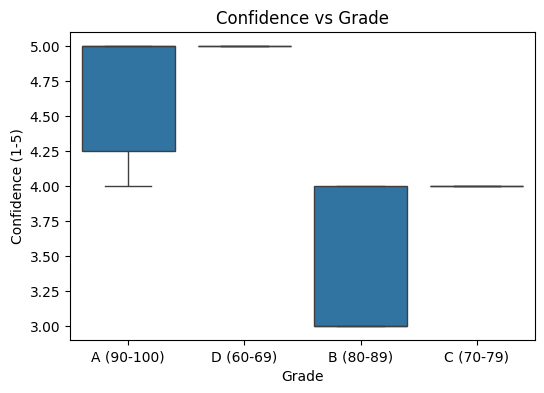

In [73]:
# Boxplot: Confidence before the practical vs Grade
plt.figure(figsize=(6,4))
sns.boxplot(x="Grade", y="How confident were you in your lab techniques before the practical?", data=df_encoded)
plt.title("Confidence vs Grade")
plt.xlabel("Grade")
plt.ylabel("Confidence (1-5)")
plt.show()


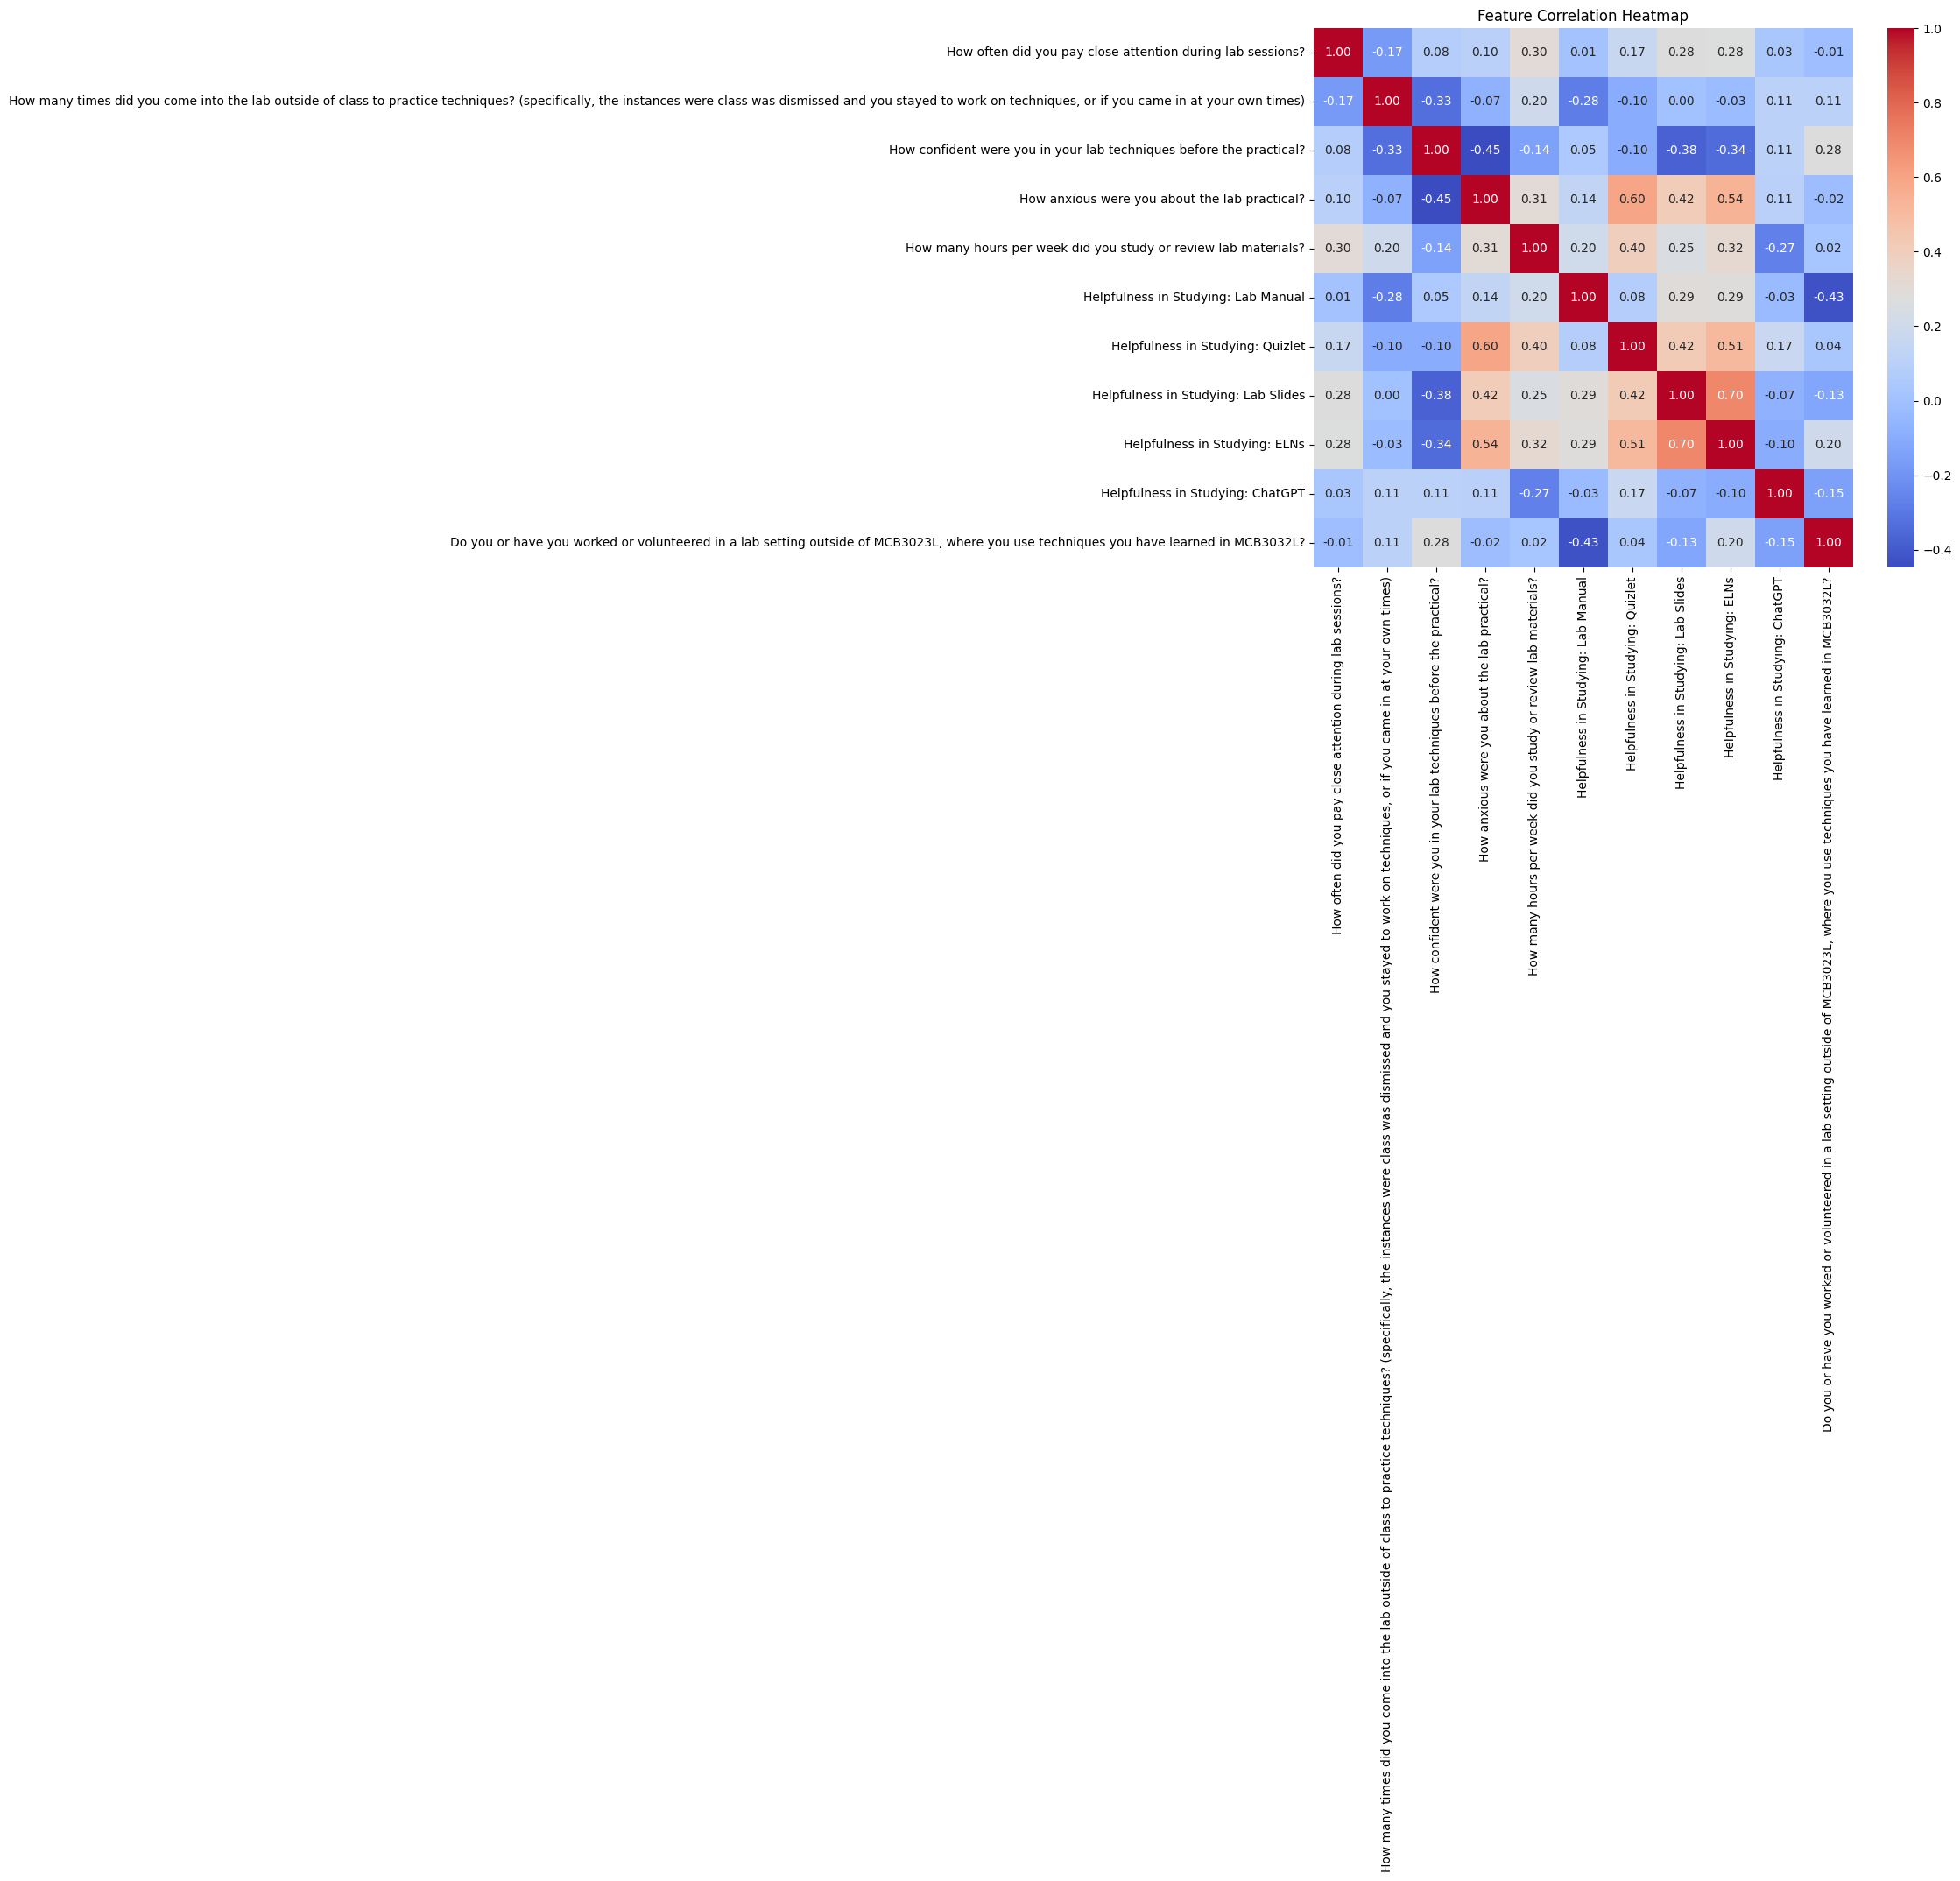

In [74]:
# Compute correlation matrix (excluding the 'Grade' column since it's categorical)
corr = df_encoded.drop(columns=["Grade"]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()


Train/Test Split
Now that we’ve cleaned and explored our dataset, we’re ready to build a machine learning model. First, we’ll split our data into two parts:

Training set (used to teach the model)

Test set (used to evaluate how well the model generalizes to new data)

We'll use an 80/20 split — 80% of the data for training, and 20% for testing.

In [75]:
# Drop classes with only 1 occurrence
grade_counts = df_encoded["Grade"].value_counts()
rare_grades = grade_counts[grade_counts < 2].index
df_encoded = df_encoded[~df_encoded["Grade"].isin(rare_grades)]


from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop(columns=["Grade"])
y = df_encoded["Grade"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify helps balance grade distribution
)

# Show shape of resulting splits
print(f"Training size: {X_train.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")


Training size: 12 rows
Test size: 3 rows


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Prepare features and target
X = df_encoded.drop(columns=["Grade"])
y = df_encoded["Grade"]

# Initialize and evaluate model
logreg = LogisticRegression(max_iter=1000)
scores = cross_val_score(logreg, X, y, cv=3)

print("Cross-validated accuracy scores:", scores)
print("Average accuracy:", np.mean(scores))

Cross-validated accuracy scores: [0.4 0.4 0.8]
Average accuracy: 0.5333333333333333


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
